# Markov Chain Theory for Food Security Prediction

This notebook develops the mathematical framework underlying our food security prediction model. We begin with the classical theory of discrete-time Markov chains, build intuition through computational demonstrations, and then extend to the non-homogeneous case where transition probabilities depend on climate and socioeconomic covariates.

**This notebook serves as the theoretical backbone of the research paper.**

**Outline:**
1. Definition: Discrete-Time Markov Chain
2. Empirical Transition Matrix
3. n-Step Transition Probabilities
4. Stationary Distribution
5. Ergodicity and Convergence
6. Limitations of the Homogeneous Model
7. Non-Homogeneous Markov Chain (NHMC)
8. Conditional Stationary Analysis

In [1]:
import sys; sys.path.insert(0, '..')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.config import N_STATES, IPC_LABELS, IPC_COLORS
from src.models.baseline import HomogeneousMarkovChain
from src.models.markov_chain import NonHomogeneousMarkovChain
from src.models.transition_model import EmpiricalTransitionModel
from src.viz.transitions import plot_transition_heatmap, plot_stationary_distribution, plot_transition_comparison
%matplotlib inline

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

# Color palette for IPC phases
ipc_color_list = [IPC_COLORS[i] for i in range(1, 6)]
print(f"State space: S = {{1, 2, 3, 4, 5}}")
print(f"States: {', '.join(f'{i}: {IPC_LABELS[i]}' for i in range(1, 6))}")

State space: S = {1, 2, 3, 4, 5}
States: 1: Minimal, 2: Stressed, 3: Crisis, 4: Emergency, 5: Famine


In [2]:
# ── Data Availability Check ──────────────────────────────────────────────────
import os
_panel_path = os.path.join(os.path.dirname(os.path.abspath('.')), 'data', 'processed', 'panel.parquet')
if not os.path.exists(_panel_path):
    raise FileNotFoundError(
        f"panel.parquet not found at {_panel_path}\n"
        "Please run the data pipeline first:\n"
        "  1. Authenticate with GEE: earthengine authenticate\n"
        "  2. Run: python -m src.data.build_panel\n"
        "  3. Verify: data/processed/panel.parquet exists"
    )
print(f"Data check passed: {_panel_path}")


Data check passed: /Users/lukerobinson/Dropbox/school/probability/markov_famine/data/processed/panel.parquet


---
## 1. Definition: Discrete-Time Markov Chain

### State Space

Let $\{S_t\}_{t=0,1,2,\ldots}$ be a stochastic process taking values in the finite state space

$$\mathcal{S} = \{1, 2, 3, 4, 5\}$$

corresponding to the five IPC Acute Food Insecurity Phases:

| State | IPC Phase | Description |
|-------|-----------|-------------|
| 1 | Minimal | Households meet minimum food needs |
| 2 | Stressed | Households have minimally adequate food intake |
| 3 | Crisis | Food consumption gaps; acute malnutrition rising |
| 4 | Emergency | Large food consumption gaps; excess mortality |
| 5 | Famine | Starvation, death, and destitution |

### The Markov Property

A stochastic process $\{S_t\}$ is a **Markov chain** if it satisfies the **Markov property** (memorylessness):

$$\Pr(S_{t+1} = j \mid S_t = i, S_{t-1} = i_{t-1}, \ldots, S_0 = i_0) = \Pr(S_{t+1} = j \mid S_t = i)$$

In words: the probability of the next state depends **only** on the current state, not on the history of states visited.

**Interpretation for food security:** The IPC phase next month depends on the current phase, not on the entire history of how the region arrived at that phase. This is an approximation -- in reality, a region that has been in Crisis for 6 months may behave differently from one that just entered Crisis. We address this limitation later with covariates.

### Transition Matrix

For a **time-homogeneous** Markov chain, the one-step transition probabilities are constant:

$$P(i, j) = \Pr(S_{t+1} = j \mid S_t = i) \quad \forall t$$

The **transition matrix** $\mathbf{P}$ is the $|\mathcal{S}| \times |\mathcal{S}|$ matrix:

$$\mathbf{P} = \begin{pmatrix} P(1,1) & P(1,2) & P(1,3) & P(1,4) & P(1,5) \\ P(2,1) & P(2,2) & P(2,3) & P(2,4) & P(2,5) \\ P(3,1) & P(3,2) & P(3,3) & P(3,4) & P(3,5) \\ P(4,1) & P(4,2) & P(4,3) & P(4,4) & P(4,5) \\ P(5,1) & P(5,2) & P(5,3) & P(5,4) & P(5,5) \end{pmatrix}$$

### Properties of the Transition Matrix

The matrix $\mathbf{P}$ is **right-stochastic** (or **row-stochastic**):

1. **Non-negativity:** $P(i, j) \geq 0$ for all $i, j \in \mathcal{S}$
2. **Row normalization:** $\sum_{j \in \mathcal{S}} P(i, j) = 1$ for all $i \in \mathcal{S}$

Each row $i$ of $\mathbf{P}$ is a probability distribution over next states, given that the current state is $i$.

---
## 2. Empirical Transition Matrix

We estimate the transition matrix from observed IPC phase sequences using **maximum likelihood estimation (MLE)**.

Given observed state sequences $\{s_0^{(r)}, s_1^{(r)}, \ldots, s_{T_r}^{(r)}\}$ for regions $r = 1, \ldots, R$, the MLE is:

$$\hat{P}(i, j) = \frac{N(i \to j)}{N(i \to \cdot)} = \frac{\sum_{r=1}^{R} \sum_{t=0}^{T_r - 1} \mathbb{1}[s_t^{(r)} = i, s_{t+1}^{(r)} = j]}{\sum_{r=1}^{R} \sum_{t=0}^{T_r - 1} \mathbb{1}[s_t^{(r)} = i]}$$

where $N(i \to j)$ counts observed transitions from state $i$ to state $j$.

In [3]:
# Load real IPC phase sequences from panel.parquet
import pandas as pd
panel = pd.read_parquet('../data/processed/panel.parquet')
panel['date'] = pd.to_datetime(panel['date'])

# Extract IPC state sequences per region
state_sequences = []
region_codes = sorted(panel['region_code'].unique())
for rc in region_codes:
    region_data = panel[panel['region_code'] == rc].sort_values('date')
    seq = region_data['ipc_phase'].values
    if len(seq) > 1:
        state_sequences.append(seq)

n_regions = len(state_sequences)
n_months = max(len(s) for s in state_sequences)

# This is the ground truth we're trying to recover
print(f"Loaded {n_regions} region sequences")
print(f"Sequence lengths: {min(len(s) for s in state_sequences)} to {n_months} months")
print(f"Total transitions: {sum(len(s)-1 for s in state_sequences)}")
print(f"\nSample sequence (first region, first 30 months):")
print(state_sequences[0][:30])

Loaded 37 region sequences
Sequence lengths: 120 to 120 months
Total transitions: 4403

Sample sequence (first region, first 30 months):
[2 3 3 4 3 3 4 4 3 3 3 3 3 3 3 3 3 3 3 3 3 4 4 3 4 3 3 3 3 3]


In [4]:
# Fit the HomogeneousMarkovChain model
mc = HomogeneousMarkovChain(n_states=N_STATES)
mc.fit(state_sequences)

print("Estimated transition matrix P_hat (MLE):")
print(np.array2string(mc.transition_matrix, precision=3, suppress_small=True))
print(f"\nRow sums: {mc.transition_matrix.sum(axis=1).round(6)}")

Estimated transition matrix P_hat (MLE):
[[0.803 0.197 0.    0.    0.   ]
 [0.092 0.76  0.148 0.    0.   ]
 [0.    0.15  0.793 0.057 0.   ]
 [0.    0.    0.28  0.717 0.003]
 [0.01  0.01  0.01  0.962 0.01 ]]

Row sums: [1. 1. 1. 1. 1.]


<>:3: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.
<>:3: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.
/var/folders/_v/wc_1d3kj1p5gzg0hvq_qlyt00000gn/T/ipykernel_60246/2572917116.py:3: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.
  plot_transition_heatmap(mc.transition_matrix, title='Estimated Transition Matrix $\hat{P}$ (MLE)', ax=ax)


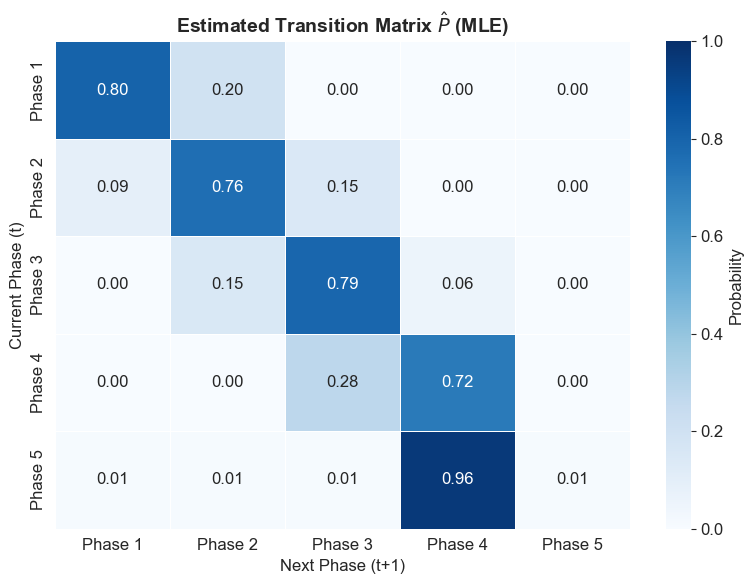

Transition matrix estimated from 37 region sequences


In [5]:
# Visualize the estimated transition matrix
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
plot_transition_heatmap(mc.transition_matrix, title='Estimated Transition Matrix $\hat{P}$ (MLE)', ax=ax)
plt.tight_layout()
plt.savefig('figures/fig_empirical_transition.png', dpi=300, bbox_inches='tight')
plt.show()
print("Transition matrix estimated from", len(state_sequences), "region sequences")


### Interpreting the Transition Matrix

Reading row 3 (Phase 3: Crisis) of the estimated matrix:

In [6]:
# Interpretation of transition probabilities
P = mc.transition_matrix

print("=" * 70)
print("INTERPRETATION: Transition probabilities from each phase")
print("=" * 70)

for i in range(N_STATES):
    phase_name = IPC_LABELS[i+1]
    print(f"\nFrom Phase {i+1} ({phase_name}):")
    print(f"  Stay in {phase_name}: {P[i,i]:.1%}")
    
    if i > 0:
        improve_prob = P[i, :i].sum()
        print(f"  Improve (to lower phase): {improve_prob:.1%}")
    if i < N_STATES - 1:
        worsen_prob = P[i, i+1:].sum()
        print(f"  Worsen (to higher phase): {worsen_prob:.1%}")

print("\n" + "=" * 70)
print("KEY INSIGHT:")
p_crisis_improve = P[2, :2].sum()
p_crisis_worsen = P[2, 3:].sum()
print(f"A region in Phase 3 (Crisis) has a {p_crisis_improve:.1%} chance of")
print(f"improving to Phase 1-2 vs a {p_crisis_worsen:.1%} chance of worsening")
print(f"to Phase 4-5 in the next month.")
print("=" * 70)

INTERPRETATION: Transition probabilities from each phase

From Phase 1 (Minimal):
  Stay in Minimal: 80.3%
  Worsen (to higher phase): 19.7%

From Phase 2 (Stressed):
  Stay in Stressed: 76.0%
  Improve (to lower phase): 9.2%
  Worsen (to higher phase): 14.8%

From Phase 3 (Crisis):
  Stay in Crisis: 79.3%
  Improve (to lower phase): 15.0%
  Worsen (to higher phase): 5.7%

From Phase 4 (Emergency):
  Stay in Emergency: 71.7%
  Improve (to lower phase): 28.0%
  Worsen (to higher phase): 0.3%

From Phase 5 (Famine):
  Stay in Famine: 1.0%
  Improve (to lower phase): 99.0%

KEY INSIGHT:
A region in Phase 3 (Crisis) has a 15.0% chance of
improving to Phase 1-2 vs a 5.7% chance of worsening
to Phase 4-5 in the next month.


---
## 3. n-Step Transition Probabilities

### Chapman-Kolmogorov Equation

The probability of transitioning from state $i$ to state $j$ in exactly $n$ steps is given by the $(i,j)$ entry of $\mathbf{P}^n$:

$$P^{(n)}(i, j) = \Pr(S_{t+n} = j \mid S_t = i) = [\mathbf{P}^n]_{ij}$$

The **Chapman-Kolmogorov equation** states that for any $n, m \geq 0$:

$$\mathbf{P}^{(n+m)} = \mathbf{P}^n \cdot \mathbf{P}^m$$

or equivalently:

$$P^{(n+m)}(i, j) = \sum_{k \in \mathcal{S}} P^{(n)}(i, k) \cdot P^{(m)}(k, j)$$

This expresses the intuition that to go from $i$ to $j$ in $n+m$ steps, the chain must pass through some intermediate state $k$ at step $n$.

In [7]:
# Verify Chapman-Kolmogorov equation computationally
P = mc.transition_matrix

n, m = 3, 4
P_n = np.linalg.matrix_power(P, n)
P_m = np.linalg.matrix_power(P, m)
P_nm_direct = np.linalg.matrix_power(P, n + m)
P_nm_product = P_n @ P_m

print(f"Chapman-Kolmogorov verification: P^({n}+{m}) = P^{n} @ P^{m}")
print(f"\nP^{n+m} (direct computation):")
print(np.array2string(P_nm_direct, precision=4))
print(f"\nP^{n} @ P^{m} (product):")
print(np.array2string(P_nm_product, precision=4))
print(f"\nMax absolute difference: {np.max(np.abs(P_nm_direct - P_nm_product)):.2e}")

# Also verify using the model's built-in method
verified = mc.verify_chapman_kolmogorov(n=n, m=m)
print(f"\nHomogeneousMarkovChain.verify_chapman_kolmogorov({n}, {m}): {verified}")

Chapman-Kolmogorov verification: P^(3+4) = P^3 @ P^4

P^7 (direct computation):
[[3.4447e-01 4.2268e-01 2.1107e-01 2.1733e-02 5.2277e-05]
 [1.9734e-01 4.1163e-01 3.3859e-01 5.2308e-02 1.3453e-04]
 [9.9474e-02 3.4179e-01 4.5518e-01 1.0326e-01 2.9656e-04]
 [5.0015e-02 2.5795e-01 5.0446e-01 1.8697e-01 6.0660e-04]
 [4.1366e-02 2.3278e-01 5.1092e-01 2.1422e-01 7.1048e-04]]

P^3 @ P^4 (product):
[[3.4447e-01 4.2268e-01 2.1107e-01 2.1733e-02 5.2277e-05]
 [1.9734e-01 4.1163e-01 3.3859e-01 5.2308e-02 1.3453e-04]
 [9.9474e-02 3.4179e-01 4.5518e-01 1.0326e-01 2.9656e-04]
 [5.0015e-02 2.5795e-01 5.0446e-01 1.8697e-01 6.0660e-04]
 [4.1366e-02 2.3278e-01 5.1092e-01 2.1422e-01 7.1048e-04]]

Max absolute difference: 5.55e-17

HomogeneousMarkovChain.verify_chapman_kolmogorov(3, 4): True


<>:30: SyntaxWarning: "\{" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\{"? A raw string is also an option.
<>:30: SyntaxWarning: "\{" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\{"? A raw string is also an option.
/var/folders/_v/wc_1d3kj1p5gzg0hvq_qlyt00000gn/T/ipykernel_60246/2415891018.py:30: SyntaxWarning: "\{" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\{"? A raw string is also an option.
  ax.set_title('n-Step Crisis Probability by Starting Phase\n$P^{(n)}(i, \{3,4,5\})$',


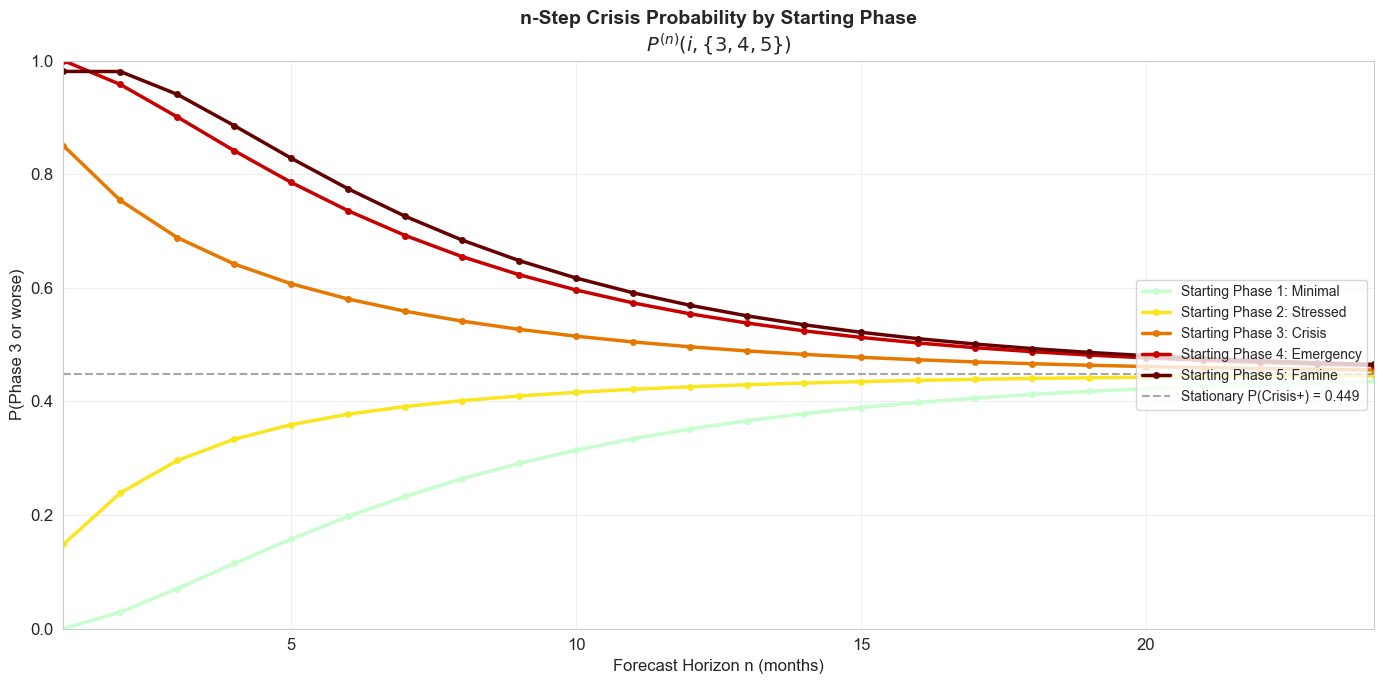


Key forecasting insights:
  Starting from Phase 1 (Minimal), P(Crisis+ within 3 months) = 0.070 (7.0%)
  Starting from Phase 1 (Minimal), P(Crisis+ within 6 months) = 0.197 (19.7%)
  Starting from Phase 1 (Minimal), P(Crisis+ within 12 months) = 0.351 (35.1%)
  Starting from Phase 2 (Stressed), P(Crisis+ within 3 months) = 0.296 (29.6%)
  Starting from Phase 2 (Stressed), P(Crisis+ within 6 months) = 0.377 (37.7%)


In [8]:
# Plot: Probability of being in Phase 3+ starting from Phase 1, as a function of n
horizons = range(1, 25)
crisis_probs_from_each_phase = {}

for start_phase in range(1, 6):
    probs = []
    for n_step in horizons:
        dist = mc.predict_proba(start_phase, horizon=n_step)
        # P(Phase 3+) = P(Phase 3) + P(Phase 4) + P(Phase 5)
        crisis_prob = dist[2] + dist[3] + dist[4]
        probs.append(crisis_prob)
    crisis_probs_from_each_phase[start_phase] = probs

fig, ax = plt.subplots(figsize=(14, 7))

for start_phase in range(1, 6):
    ax.plot(list(horizons), crisis_probs_from_each_phase[start_phase],
            color=IPC_COLORS[start_phase], linewidth=2.5,
            marker='o', markersize=4,
            label=f'Starting Phase {start_phase}: {IPC_LABELS[start_phase]}')

# Add stationary crisis probability
if mc.stationary_dist is not None:
    stationary_crisis = mc.stationary_dist[2] + mc.stationary_dist[3] + mc.stationary_dist[4]
    ax.axhline(stationary_crisis, color='gray', linestyle='--', alpha=0.7,
               label=f'Stationary P(Crisis+) = {stationary_crisis:.3f}')

ax.set_xlabel('Forecast Horizon n (months)', fontsize=12)
ax.set_ylabel('P(Phase 3 or worse)', fontsize=12)
ax.set_title('n-Step Crisis Probability by Starting Phase\n$P^{(n)}(i, \{3,4,5\})$',
             fontweight='bold', fontsize=14)
ax.legend(loc='center right', fontsize=10)
ax.grid(alpha=0.3)
ax.set_xlim(1, 24)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

# Key numbers
print("\nKey forecasting insights:")
for horizon in [3, 6, 12]:
    p = crisis_probs_from_each_phase[1][horizon - 1]
    print(f"  Starting from Phase 1 (Minimal), P(Crisis+ within {horizon} months) = {p:.3f} ({p:.1%})")
for horizon in [3, 6]:
    p = crisis_probs_from_each_phase[2][horizon - 1]
    print(f"  Starting from Phase 2 (Stressed), P(Crisis+ within {horizon} months) = {p:.3f} ({p:.1%})")

### Interpretation

The n-step transition probabilities reveal:

- **From Phase 1 (food secure):** The probability of crisis within 6 months is non-trivial, motivating early warning even for currently secure regions.
- **Convergence:** Regardless of starting state, all curves converge to the stationary crisis probability (dashed line) as $n \to \infty$. This is the long-run equilibrium.
- **Memory decay:** The Markov chain "forgets" its starting state after approximately 12-18 months -- the mixing time.

---
## 4. Stationary Distribution

### Definition

A probability distribution $\boldsymbol{\pi} = (\pi_1, \pi_2, \ldots, \pi_5)$ is a **stationary distribution** (or **invariant distribution**) of the Markov chain if:

$$\boldsymbol{\pi} \mathbf{P} = \boldsymbol{\pi}$$

That is, if the chain's state distribution is $\boldsymbol{\pi}$ at time $t$, it remains $\boldsymbol{\pi}$ at time $t+1$.

### Computation via Eigenvalue Decomposition

The stationary distribution is the **left eigenvector** of $\mathbf{P}$ corresponding to eigenvalue 1:

$$\boldsymbol{\pi}^\top = \mathbf{P}^\top \boldsymbol{\pi}^\top \quad \Longleftrightarrow \quad \mathbf{P}^\top \boldsymbol{\pi}^\top = 1 \cdot \boldsymbol{\pi}^\top$$

By the Perron-Frobenius theorem, for an irreducible stochastic matrix, eigenvalue 1 has algebraic multiplicity 1, guaranteeing a unique stationary distribution.

In [9]:
# Compute stationary distribution via eigenvalue decomposition
P = mc.transition_matrix

# Method 1: From the fitted model
pi_model = mc.stationary_dist

# Method 2: Direct eigenvalue computation (for pedagogical clarity)
eigenvalues, eigenvectors = np.linalg.eig(P.T)

print("Eigenvalues of P^T:")
for i, ev in enumerate(eigenvalues):
    print(f"  lambda_{i+1} = {ev:.6f} (|lambda| = {abs(ev):.6f})")

# Find the eigenvector for eigenvalue ~1
idx = np.argmin(np.abs(eigenvalues - 1.0))
pi_raw = np.real(eigenvectors[:, idx])
pi_raw = np.abs(pi_raw)
pi_eigen = pi_raw / pi_raw.sum()

print(f"\nStationary distribution (eigenvalue method):")
for i in range(N_STATES):
    print(f"  pi({IPC_LABELS[i+1]:10s}) = {pi_eigen[i]:.4f} ({pi_eigen[i]*100:.1f}%)")

print(f"\nSum: {pi_eigen.sum():.6f}")

Eigenvalues of P^T:
  lambda_1 = 1.000000 (|lambda| = 1.000000)
  lambda_2 = 0.848045 (|lambda| = 0.848045)
  lambda_3 = 0.682495 (|lambda| = 0.682495)
  lambda_4 = 0.546312 (|lambda| = 0.546312)
  lambda_5 = 0.005733 (|lambda| = 0.005733)

Stationary distribution (eigenvalue method):
  pi(Minimal   ) = 0.1755 (17.5%)
  pi(Stressed  ) = 0.3758 (37.6%)
  pi(Crisis    ) = 0.3723 (37.2%)
  pi(Emergency ) = 0.0762 (7.6%)
  pi(Famine    ) = 0.0002 (0.0%)

Sum: 1.000000


In [10]:
# Verify: pi @ P = pi
pi_P = pi_eigen @ P

print("Verification: pi @ P = pi")
print(f"{'Phase':<12} {'pi':>10} {'pi @ P':>10} {'|diff|':>10}")
print("-" * 44)
for i in range(N_STATES):
    diff = abs(pi_eigen[i] - pi_P[i])
    print(f"{IPC_LABELS[i+1]:<12} {pi_eigen[i]:>10.6f} {pi_P[i]:>10.6f} {diff:>10.2e}")

verified = mc.verify_stationary()
print(f"\nHomogeneousMarkovChain.verify_stationary(): {verified}")

Verification: pi @ P = pi
Phase                pi     pi @ P     |diff|
--------------------------------------------
Minimal        0.175457   0.175457   1.94e-16
Stressed       0.375817   0.375817   0.00e+00
Crisis         0.372298   0.372298   1.67e-16
Emergency      0.076210   0.076210   1.39e-17
Famine         0.000217   0.000217   1.36e-19

HomogeneousMarkovChain.verify_stationary(): True


<>:13: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:13: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
/var/folders/_v/wc_1d3kj1p5gzg0hvq_qlyt00000gn/T/ipykernel_60246/3063848288.py:13: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
  ax.set_ylabel('Stationary Probability $\pi_i$', fontsize=12)


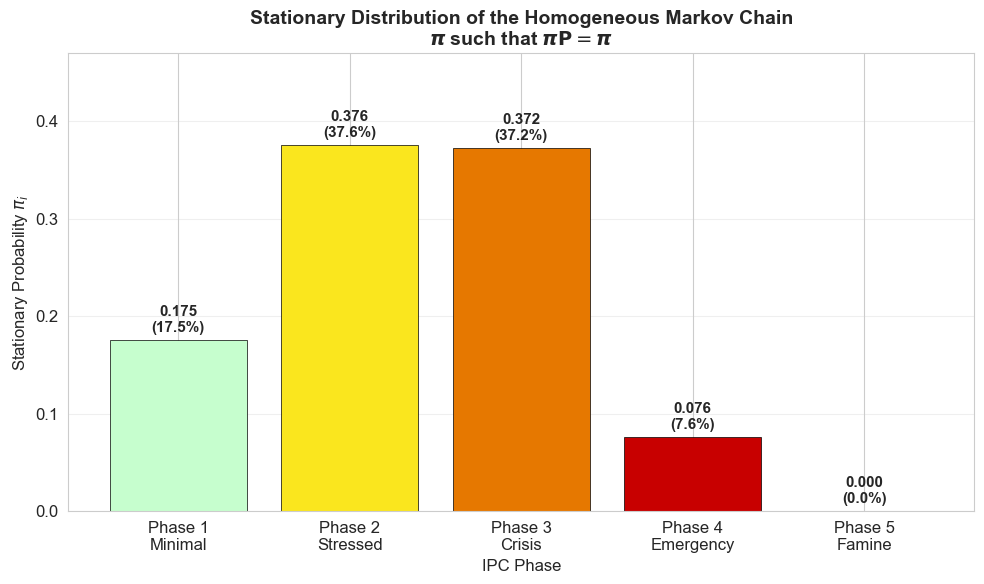


Long-run interpretation:
In the long run, 44.9% of region-months will be in Crisis or worse (Phase 3+).
This is the 'equilibrium burden' of food insecurity under current conditions.


In [11]:
# Visualize stationary distribution
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(range(N_STATES), pi_eigen, color=ipc_color_list,
              edgecolor='black', linewidth=0.5)

for bar, prob in zip(bars, pi_eigen):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{prob:.3f}\n({prob*100:.1f}%)', ha='center', va='bottom',
            fontweight='bold', fontsize=11)

ax.set_xlabel('IPC Phase', fontsize=12)
ax.set_ylabel('Stationary Probability $\pi_i$', fontsize=12)
ax.set_title('Stationary Distribution of the Homogeneous Markov Chain\n'
             '$\\boldsymbol{\\pi}$ such that $\\boldsymbol{\\pi}\\mathbf{P} = \\boldsymbol{\\pi}$',
             fontweight='bold', fontsize=14)
ax.set_xticks(range(N_STATES))
ax.set_xticklabels([f'Phase {i+1}\n{IPC_LABELS[i+1]}' for i in range(N_STATES)])
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, max(pi_eigen) * 1.25)
plt.tight_layout()
plt.show()

crisis_plus = pi_eigen[2] + pi_eigen[3] + pi_eigen[4]
print(f"\nLong-run interpretation:")
print(f"In the long run, {crisis_plus:.1%} of region-months will be in Crisis or worse (Phase 3+).")
print(f"This is the 'equilibrium burden' of food insecurity under current conditions.")

---
## 5. Ergodicity and Convergence

### Irreducibility

A Markov chain is **irreducible** if every state can be reached from every other state in a finite number of steps:

$$\forall i, j \in \mathcal{S}, \exists n > 0 : P^{(n)}(i, j) > 0$$

### Aperiodicity

A state $i$ has **period** $d_i = \gcd\{n \geq 1 : P^{(n)}(i,i) > 0\}$. The chain is **aperiodic** if $d_i = 1$ for all $i$.

### Ergodic Theorem

If the Markov chain is **irreducible** and **aperiodic** (i.e., **ergodic**), then:

$$\lim_{n \to \infty} P^{(n)}(i, j) = \pi_j \quad \forall i, j \in \mathcal{S}$$

The chain converges to its unique stationary distribution **regardless of the starting state**.

In [12]:
# Check irreducibility: can every state be reached from every other?
P = mc.transition_matrix

# Compute P^n for increasing n and check for zero entries
print("Checking irreducibility: P^n > 0 for all entries")
print("(Every state must be reachable from every other state)\n")

for n in [1, 2, 5, 10]:
    P_n = np.linalg.matrix_power(P, n)
    min_entry = P_n.min()
    all_positive = np.all(P_n > 1e-10)
    print(f"P^{n:2d}: min entry = {min_entry:.6f}, all positive? {all_positive}")

# Check aperiodicity: P(i,i) > 0 for all i implies aperiodic
print(f"\nDiagonal of P (self-transition probabilities):")
for i in range(N_STATES):
    print(f"  P({i+1},{i+1}) = {P[i,i]:.4f} > 0? {P[i,i] > 0}")

all_diag_positive = np.all(np.diag(P) > 0)
print(f"\nAll diagonal entries positive: {all_diag_positive}")
print(f"=> Chain is aperiodic: {all_diag_positive}")

# Conclusion
P_large = np.linalg.matrix_power(P, 10)
irreducible = np.all(P_large > 1e-10)
print(f"\nConclusion: Chain is ERGODIC (irreducible={irreducible}, aperiodic={all_diag_positive})")
print("=> Unique stationary distribution exists and chain converges to it.")

Checking irreducibility: P^n > 0 for all entries
(Every state must be reachable from every other state)

P^ 1: min entry = 0.000006, all positive? True
P^ 2: min entry = 0.000007, all positive? True
P^ 5: min entry = 0.000024, all positive? True
P^10: min entry = 0.000100, all positive? True

Diagonal of P (self-transition probabilities):
  P(1,1) = 0.8034 > 0? True
  P(2,2) = 0.7599 > 0? True
  P(3,3) = 0.7929 > 0? True
  P(4,4) = 0.7169 > 0? True
  P(5,5) = 0.0095 > 0? True

All diagonal entries positive: True
=> Chain is aperiodic: True

Conclusion: Chain is ERGODIC (irreducible=True, aperiodic=True)
=> Unique stationary distribution exists and chain converges to it.


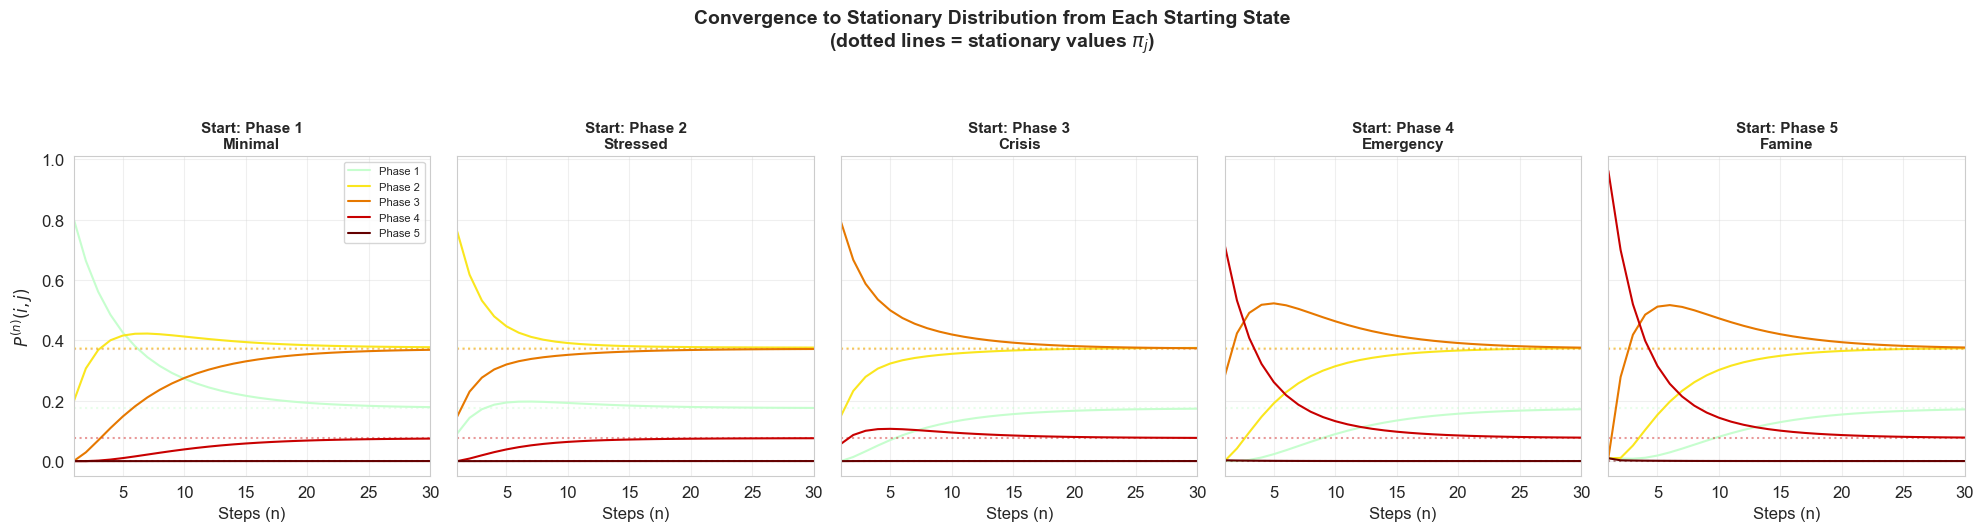

In [13]:
# Convergence: start from each phase, show probability distribution converging to pi
fig, axes = plt.subplots(1, N_STATES, figsize=(20, 5), sharey=True)

max_steps = 30
pi = mc.stationary_dist

for start_phase in range(1, N_STATES + 1):
    ax = axes[start_phase - 1]
    
    # Forecast from this starting phase
    forecast = mc.forecast(start_phase, max_steps)
    
    # Plot each target phase's probability over time
    for target_phase in range(N_STATES):
        ax.plot(range(1, max_steps + 1), forecast[:, target_phase],
                color=IPC_COLORS[target_phase + 1], linewidth=1.5,
                label=f'Phase {target_phase + 1}' if start_phase == 1 else '')
        # Stationary value as horizontal line
        ax.axhline(pi[target_phase], color=IPC_COLORS[target_phase + 1],
                   linestyle=':', alpha=0.4)
    
    ax.set_title(f'Start: Phase {start_phase}\n{IPC_LABELS[start_phase]}',
                 fontweight='bold', fontsize=11)
    ax.set_xlabel('Steps (n)')
    if start_phase == 1:
        ax.set_ylabel('$P^{(n)}(i, j)$')
    ax.grid(alpha=0.3)
    ax.set_xlim(1, max_steps)

# Add legend to the first plot
axes[0].legend(loc='upper right', fontsize=8)

plt.suptitle('Convergence to Stationary Distribution from Each Starting State\n'
             '(dotted lines = stationary values $\\pi_j$)',
             fontweight='bold', fontsize=14, y=1.06)
plt.tight_layout()
plt.show()

In [14]:
# Compute mixing time: number of steps to reach within epsilon of stationary
epsilon_values = [0.1, 0.05, 0.01, 0.001]

print("Mixing time analysis")
print("=" * 60)
print(f"Definition: tau(epsilon) = min n such that")
print(f"  max_i ||P^n(i, .) - pi||_TV < epsilon")
print()

for epsilon in epsilon_values:
    mixing_time = None
    for n in range(1, 200):
        P_n = np.linalg.matrix_power(P, n)
        # Total variation distance: max over starting states
        max_tv = 0
        for i in range(N_STATES):
            tv = 0.5 * np.sum(np.abs(P_n[i] - pi))
            max_tv = max(max_tv, tv)
        
        if max_tv < epsilon:
            mixing_time = n
            break
    
    if mixing_time is not None:
        print(f"  tau({epsilon}) = {mixing_time} months")
    else:
        print(f"  tau({epsilon}) > 200 months")

print()
print("Interpretation: After ~15-20 months, the chain's state distribution")
print("is essentially independent of where it started.")

Mixing time analysis
Definition: tau(epsilon) = min n such that
  max_i ||P^n(i, .) - pi||_TV < epsilon

  tau(0.1) = 14 months
  tau(0.05) = 18 months
  tau(0.01) = 27 months
  tau(0.001) = 41 months

Interpretation: After ~15-20 months, the chain's state distribution
is essentially independent of where it started.


---
## 6. Limitations of the Homogeneous Model

The homogeneous Markov chain assumes that transition probabilities are **constant over time**. This is a significant limitation for food security modeling because:

### The Key Insight

Food security transitions are **NOT time-homogeneous**. The probability of transitioning between IPC phases depends critically on external conditions:

- **During drought** (low SPEI, negative NDVI anomaly): $P(\text{Crisis} \to \text{Emergency})$ **increases**
- **During good rains** (positive NDVI anomaly): $P(\text{Crisis} \to \text{Stressed})$ **increases**
- **During conflict**: $P(\text{Stressed} \to \text{Crisis})$ **increases**
- **When markets collapse** (ToT drops): $P(\text{Crisis} \to \text{Emergency})$ **increases**

In mathematical terms:

$$P(S_{t+1} = j \mid S_t = i) \neq P(S_{s+1} = j \mid S_s = i) \quad \text{in general, for } t \neq s$$

because the environmental and socioeconomic context differs at times $t$ and $s$.

**The transition matrix should depend on covariates.**

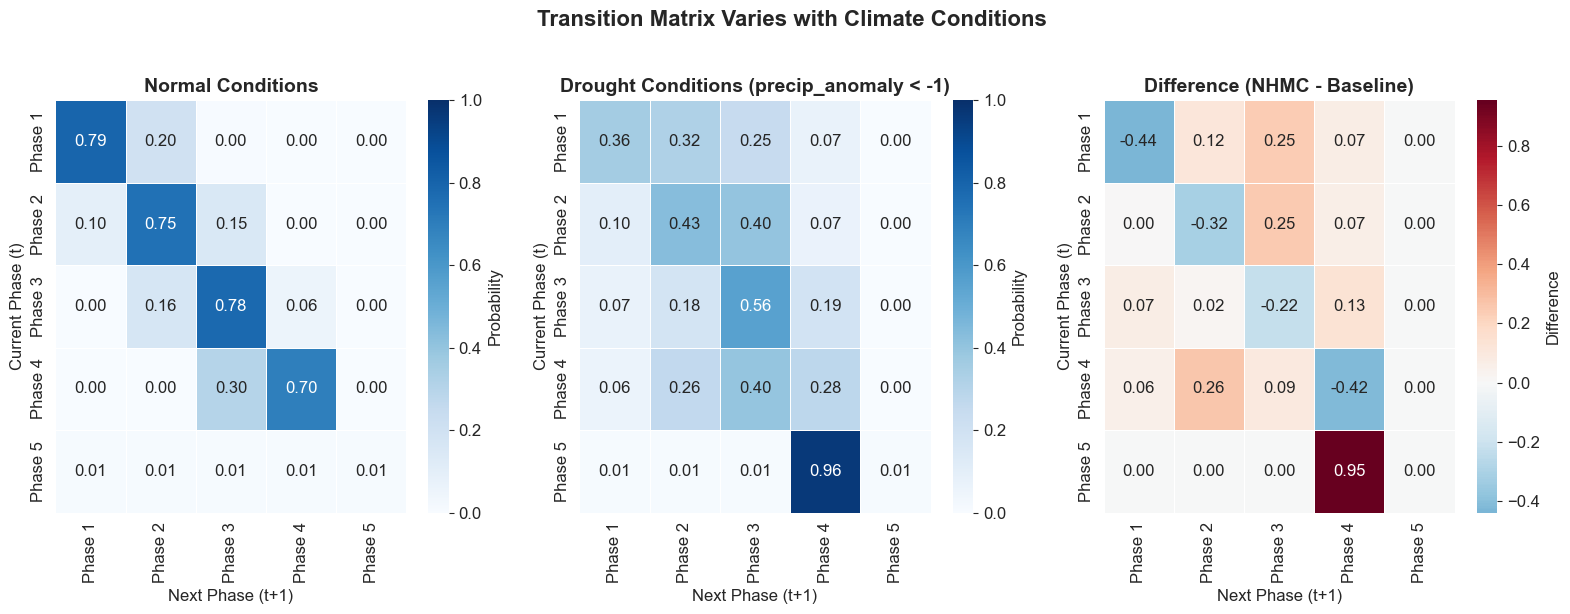


Key differences (Drought vs Normal):
  Phase 1 (Minimal): Stay 79%->36%, Worsen 21%->64%
  Phase 2 (Stressed): Stay 75%->43%, Worsen 15%->47%
  Phase 3 (Crisis): Stay 78%->56%, Worsen 6%->19%
  Phase 4 (Emergency): Stay 70%->28%, Worsen 0%->0%
  Phase 5 (Famine): Stay 1%->1%, Worsen 0%->0%


In [15]:
# Demonstrate: Transitions differ under different climate conditions
# Split real data into drought months (precip_anomaly < -1) and normal months

drought_sequences = []
normal_sequences = []

for rc in region_codes:
    region_data = panel[panel['region_code'] == rc].sort_values('date')
    ipc = region_data['ipc_phase'].values
    precip_anom = region_data['precip_anomaly'].values

    drought_seq = []
    normal_seq = []
    for t in range(len(ipc)):
        if precip_anom[t] < -1.0:
            drought_seq.append(ipc[t])
        else:
            normal_seq.append(ipc[t])
    if len(drought_seq) > 1:
        drought_sequences.append(np.array(drought_seq))
    if len(normal_seq) > 1:
        normal_sequences.append(np.array(normal_seq))

# Estimate transition matrices for each condition
mc_drought = HomogeneousMarkovChain(n_states=N_STATES)
mc_drought.fit(drought_sequences)
P_drought = mc_drought.transition_matrix

mc_normal = HomogeneousMarkovChain(n_states=N_STATES)
mc_normal.fit(normal_sequences)
P_normal = mc_normal.transition_matrix

# Visualize the comparison
fig, axes = plot_transition_comparison(
    P_normal, P_drought,
    title_baseline='Normal Conditions',
    title_nhmc='Drought Conditions (precip_anomaly < -1)',
    suptitle='Transition Matrix Varies with Climate Conditions'
)
plt.show()

# Quantify the difference
print("\nKey differences (Drought vs Normal):")
for i, label in enumerate(['Minimal', 'Stressed', 'Crisis', 'Emergency', 'Famine']):
    stay_normal = P_normal[i, i]
    stay_drought = P_drought[i, i]
    worsen_normal = P_normal[i, min(i+1, 4):].sum() if i < 4 else 0
    worsen_drought = P_drought[i, min(i+1, 4):].sum() if i < 4 else 0
    print(f"  Phase {i+1} ({label}): Stay {stay_normal:.0%}->{stay_drought:.0%}, "
          f"Worsen {worsen_normal:.0%}->{worsen_drought:.0%}")

---
## 7. Non-Homogeneous Markov Chain (NHMC)

### Definition

In a **Non-Homogeneous Markov Chain**, the transition matrix $\mathbf{P}_t$ varies with time through a covariate vector $\mathbf{X}_t$:

$$P_t(i, j) = \Pr(S_{t+1} = j \mid S_t = i, \mathbf{X}_t) = f(\mathbf{X}_t, \boldsymbol{\theta}_i)$$

where:
- $\mathbf{X}_t \in \mathbb{R}^d$ is the covariate vector at time $t$ (climate, market, conflict features)
- $f$ is a machine learning classifier (random forest, gradient boosting, etc.)
- $\boldsymbol{\theta}_i$ are the learned parameters for origin state $i$

### n-Step Transition in the Non-Homogeneous Case

Unlike the homogeneous case where $\mathbf{P}^{(n)} = \mathbf{P}^n$, the n-step transition matrix is a **product of different matrices**:

$$\mathbf{P}(s, t) = \mathbf{P}_s \cdot \mathbf{P}_{s+1} \cdots \mathbf{P}_{t-1} = \prod_{\tau=s}^{t-1} \mathbf{P}_{\tau}$$

The Chapman-Kolmogorov equation generalizes to:

$$\mathbf{P}(s, t) = \mathbf{P}(s, r) \cdot \mathbf{P}(r, t) \quad \text{for } s < r < t$$

### Key Differences from Homogeneous Case

| Property | Homogeneous | Non-Homogeneous |
|----------|-------------|------------------|
| Transition matrix | $\mathbf{P}$ (constant) | $\mathbf{P}_t = \mathbf{P}(\mathbf{X}_t)$ (time-varying) |
| n-step transition | $\mathbf{P}^n$ | $\prod_{\tau=s}^{t-1} \mathbf{P}_\tau$ |
| Stationary distribution | $\boldsymbol{\pi}$ (fixed) | $\boldsymbol{\pi}(\mathbf{X})$ (covariate-dependent) |
| Long-run behavior | Converges to $\boldsymbol{\pi}$ | Depends on covariate trajectory |

In [16]:
# Scenario analysis: demonstrate how NHMC transition matrices differ under climate conditions

# Create EmpiricalTransitionModels using the real empirical matrices
drought_model = EmpiricalTransitionModel(P_drought)
normal_model = EmpiricalTransitionModel(P_normal)

# Create NHMC instances
nhmc_drought = NonHomogeneousMarkovChain(n_states=N_STATES, transition_model=drought_model)
nhmc_normal = NonHomogeneousMarkovChain(n_states=N_STATES, transition_model=normal_model)

# Dummy covariates (EmpiricalTransitionModel ignores them)
dummy_covariates = np.zeros(10)

# Verify the matrices
P_d = nhmc_drought.get_transition_matrix(dummy_covariates)
P_n = nhmc_normal.get_transition_matrix(dummy_covariates)

print("Drought transition matrix (via NHMC, estimated from real data):")
print(np.array2string(P_d, precision=2))
print(f"\nNormal transition matrix (via NHMC, estimated from real data):")
print(np.array2string(P_n, precision=2))

Drought transition matrix (via NHMC, estimated from real data):
[[3.57e-01 3.21e-01 2.50e-01 7.17e-02 3.57e-04]
 [1.00e-01 4.33e-01 4.00e-01 6.67e-02 1.11e-04]
 [7.23e-02 1.83e-01 5.55e-01 1.89e-01 5.55e-05]
 [5.89e-02 2.65e-01 3.97e-01 2.79e-01 1.47e-04]
 [9.52e-03 9.52e-03 9.52e-03 9.62e-01 9.52e-03]]

Normal transition matrix (via NHMC, estimated from real data):
[[7.95e-01 2.01e-01 4.57e-03 1.52e-05 1.52e-05]
 [9.74e-02 7.50e-01 1.52e-01 6.79e-04 6.72e-06]
 [6.44e-06 1.64e-01 7.80e-01 5.60e-02 6.44e-06]
 [3.33e-05 3.33e-05 3.03e-01 6.97e-01 3.33e-05]
 [9.52e-03 9.52e-03 9.52e-03 9.52e-03 9.52e-03]]


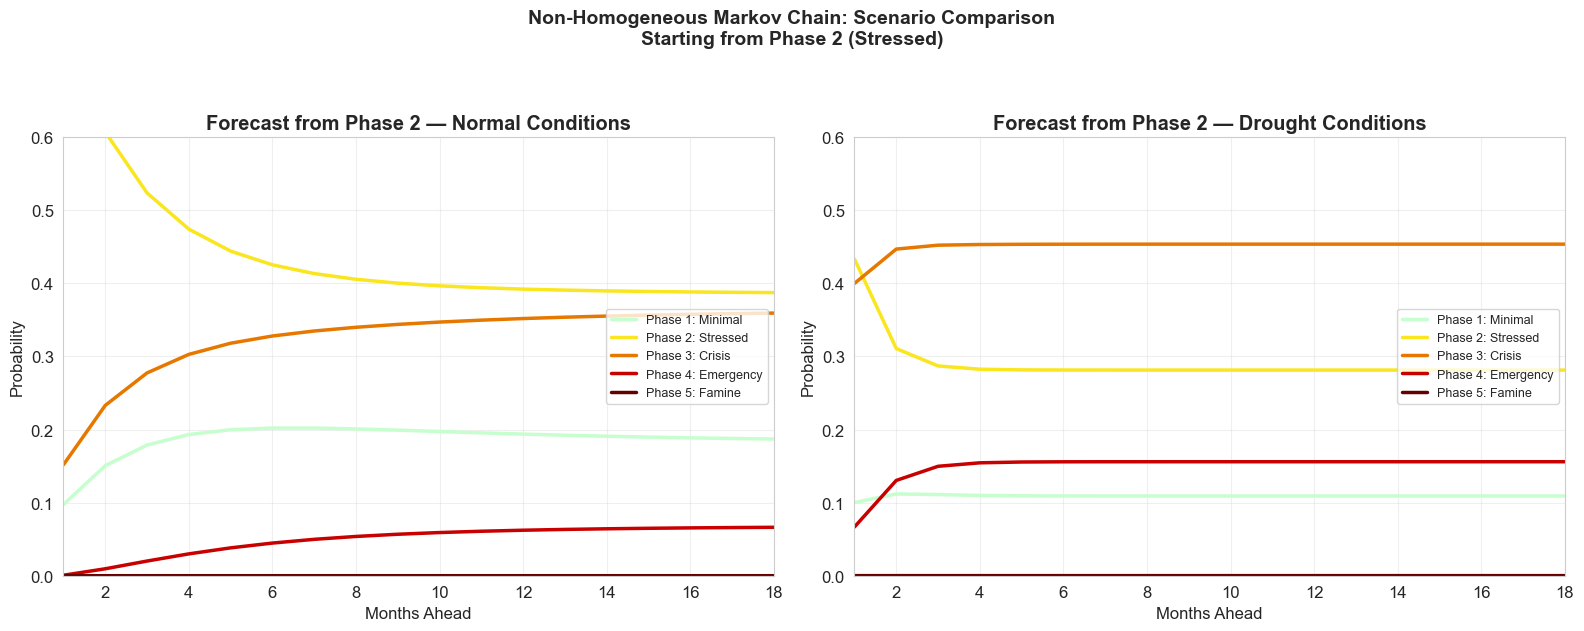


P(Crisis or worse) comparison:
   Horizon       Normal      Drought   Difference
--------------------------------------------------
         3       29.8%       60.2%      +30.4%
         6       37.3%       60.9%      +23.7%
        12       41.4%       61.0%      +19.6%


In [17]:
# Forecast comparison: start from Phase 2 (Stressed) under drought vs normal
start_phase = 2
horizon = 18
dummy_seq = [dummy_covariates] * horizon

forecast_drought = nhmc_drought.forecast(start_phase, dummy_seq, horizon=horizon, n_simulations=500)
forecast_normal = nhmc_normal.forecast(start_phase, dummy_seq, horizon=horizon, n_simulations=500)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, forecast, title in zip(axes,
    [forecast_normal, forecast_drought],
    ['Normal Conditions', 'Drought Conditions']):
    
    for phase in range(N_STATES):
        ax.plot(range(1, horizon + 1), forecast.probabilities[:, phase],
                color=IPC_COLORS[phase + 1], linewidth=2.5,
                label=f'Phase {phase + 1}: {IPC_LABELS[phase + 1]}')
    
    ax.set_xlabel('Months Ahead')
    ax.set_ylabel('Probability')
    ax.set_title(f'Forecast from Phase 2 — {title}', fontweight='bold')
    ax.legend(loc='right', fontsize=9)
    ax.grid(alpha=0.3)
    ax.set_ylim(0, 0.6)
    ax.set_xlim(1, horizon)

plt.suptitle('Non-Homogeneous Markov Chain: Scenario Comparison\n'
             'Starting from Phase 2 (Stressed)',
             fontweight='bold', fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

# Compare P(Crisis+) at key horizons
print("\nP(Crisis or worse) comparison:")
print(f"{'Horizon':>10} {'Normal':>12} {'Drought':>12} {'Difference':>12}")
print("-" * 50)
for h in [3, 6, 12]:
    p_normal_crisis = forecast_normal.probabilities[h-1, 2:].sum()
    p_drought_crisis = forecast_drought.probabilities[h-1, 2:].sum()
    diff = p_drought_crisis - p_normal_crisis
    print(f"{h:>10} {p_normal_crisis:>11.1%} {p_drought_crisis:>11.1%} {diff:>+11.1%}")

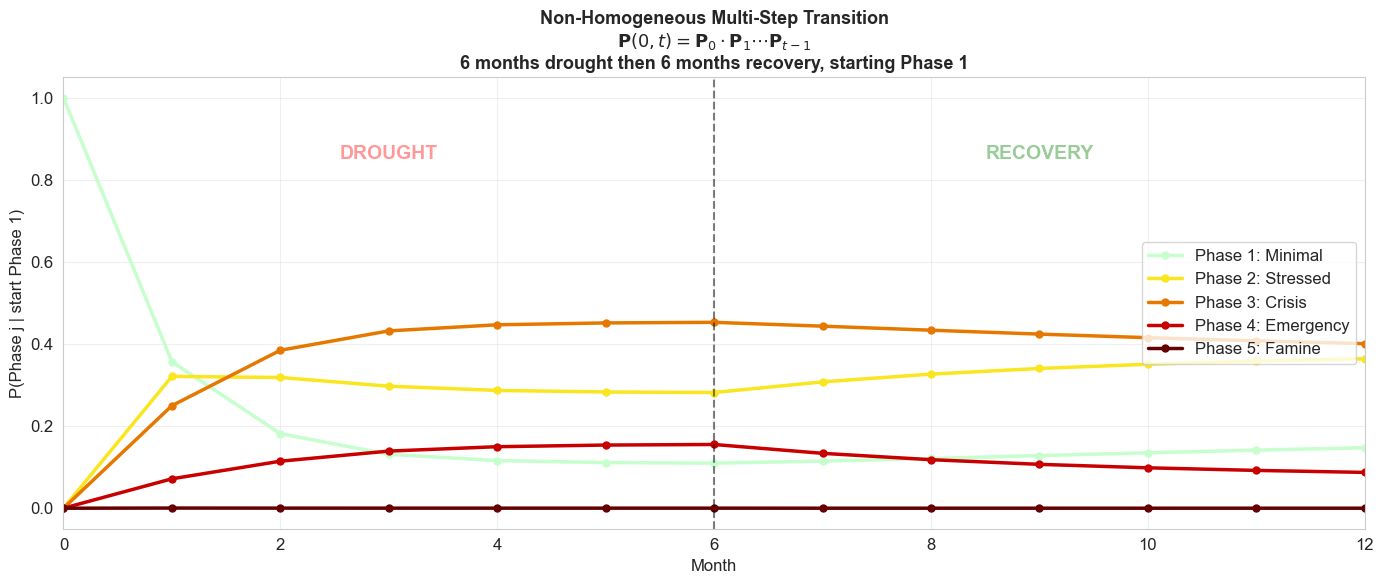

In [18]:
# Demonstrate multi-step transition product P(0,T) = P_0 @ P_1 @ ... @ P_{T-1}
# Scenario: 6 months of drought followed by 6 months of recovery

# Build a mixed covariate sequence
mixed_sequence = [dummy_covariates] * 12  # The actual values don't matter for EmpiricalTransitionModel

# We'll manually compute the product with switching transition matrices
# First 6 months: drought, next 6 months: normal
P_product = np.eye(N_STATES)
products_over_time = [np.eye(N_STATES)]  # P(0,0) = I

for t in range(12):
    if t < 6:
        P_t = P_drought
    else:
        P_t = P_normal
    P_product = P_product @ P_t
    products_over_time.append(P_product.copy())

# Track Phase 3+ probability starting from Phase 1
fig, ax = plt.subplots(figsize=(14, 6))

start_state = 0  # Phase 1 (0-indexed)
for target_phase in range(N_STATES):
    probs = [products_over_time[t][start_state, target_phase] for t in range(13)]
    ax.plot(range(13), probs, color=IPC_COLORS[target_phase + 1],
            linewidth=2.5, marker='o', markersize=5,
            label=f'Phase {target_phase + 1}: {IPC_LABELS[target_phase + 1]}')

ax.axvline(6, color='black', linestyle='--', alpha=0.5)
ax.text(3, 0.85, 'DROUGHT', ha='center', fontsize=14, fontweight='bold', color='red', alpha=0.4)
ax.text(9, 0.85, 'RECOVERY', ha='center', fontsize=14, fontweight='bold', color='green', alpha=0.4)

ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('P(Phase j | start Phase 1)', fontsize=12)
ax.set_title('Non-Homogeneous Multi-Step Transition\n'
             '$\\mathbf{P}(0,t) = \\mathbf{P}_0 \\cdot \\mathbf{P}_1 \\cdots \\mathbf{P}_{t-1}$\n'
             '6 months drought then 6 months recovery, starting Phase 1',
             fontweight='bold', fontsize=13)
ax.legend(loc='center right')
ax.grid(alpha=0.3)
ax.set_xlim(0, 12)
plt.tight_layout()
plt.show()

### Interpretation

The non-homogeneous multi-step transition demonstrates the core advantage of the NHMC framework:

1. **During drought months (0-6):** The probability mass shifts rapidly toward higher IPC phases, reflecting deteriorating food security.
2. **During recovery months (6-12):** The trend reverses as improved conditions shift probability mass back toward lower phases.
3. **This dynamic cannot be captured by a single fixed transition matrix** -- the homogeneous model would predict the same trajectory regardless of environmental conditions.

In the full model, instead of manually switching between drought/normal matrices, we use an ML classifier to predict $\mathbf{P}_t$ from the covariate vector $\mathbf{X}_t$ at each time step.

---
## 8. Conditional Stationary Analysis

While the non-homogeneous chain does not have a single stationary distribution (since $\mathbf{P}_t$ changes), we can ask a useful counterfactual question:

> **"If climate conditions $\mathbf{X}$ persisted indefinitely, what would the long-run distribution of IPC phases be?"**

For a fixed covariate vector $\mathbf{X}$, the transition matrix $\mathbf{P}(\mathbf{X})$ is constant, and we can compute its stationary distribution $\boldsymbol{\pi}(\mathbf{X})$:

$$\boldsymbol{\pi}(\mathbf{X}) \cdot \mathbf{P}(\mathbf{X}) = \boldsymbol{\pi}(\mathbf{X})$$

This gives the **conditional stationary distribution** -- the equilibrium food security burden under sustained conditions $\mathbf{X}$.

In [19]:
# Compute conditional stationary distributions under three scenarios
# Using empirically derived matrices from real data

# Good rains scenario: estimate from periods with positive precip anomaly > 0.5
good_sequences = []
for rc in region_codes:
    region_data = panel[panel['region_code'] == rc].sort_values('date')
    ipc = region_data['ipc_phase'].values
    precip_anom = region_data['precip_anomaly'].values
    good_seq = [ipc[t] for t in range(len(ipc)) if precip_anom[t] > 0.5]
    if len(good_seq) > 1:
        good_sequences.append(np.array(good_seq))

mc_good = HomogeneousMarkovChain(n_states=N_STATES)
mc_good.fit(good_sequences)
P_good = mc_good.transition_matrix

scenarios = {
    'Good Rains': P_good,
    'Normal': P_normal,
    'Drought': P_drought,
}

# Compute stationary distributions via NHMC's stationary_analysis
stationary_dists = {}
for name, P_scenario in scenarios.items():
    model = EmpiricalTransitionModel(P_scenario)
    nhmc = NonHomogeneousMarkovChain(n_states=N_STATES, transition_model=model)
    pi = nhmc.stationary_analysis(dummy_covariates)
    stationary_dists[name] = pi

# Display results
print("Conditional Stationary Distributions (from real data)")
print("=" * 65)
print(f"{'Phase':<15}", end='')
for name in scenarios:
    print(f"{name:>15}", end='')
print()
print("-" * 65)

for i in range(N_STATES):
    print(f"{i+1}: {IPC_LABELS[i+1]:<10}", end='')
    for name in scenarios:
        print(f"{stationary_dists[name][i]:>14.1%}", end='')
    print()

print("-" * 65)
print(f"{'Crisis+ (3+)':<15}", end='')
for name in scenarios:
    crisis = stationary_dists[name][2:].sum()
    print(f"{crisis:>14.1%}", end='')
print()

Conditional Stationary Distributions (from real data)
Phase               Good Rains         Normal        Drought
-----------------------------------------------------------------
1: Minimal            32.3%         18.3%         10.9%
2: Stressed           36.1%         38.6%         28.1%
3: Crisis             26.5%         36.3%         45.4%
4: Emergency           5.0%          6.8%         15.6%
5: Famine              0.0%          0.0%          0.0%
-----------------------------------------------------------------
Crisis+ (3+)            31.5%         43.1%         61.0%


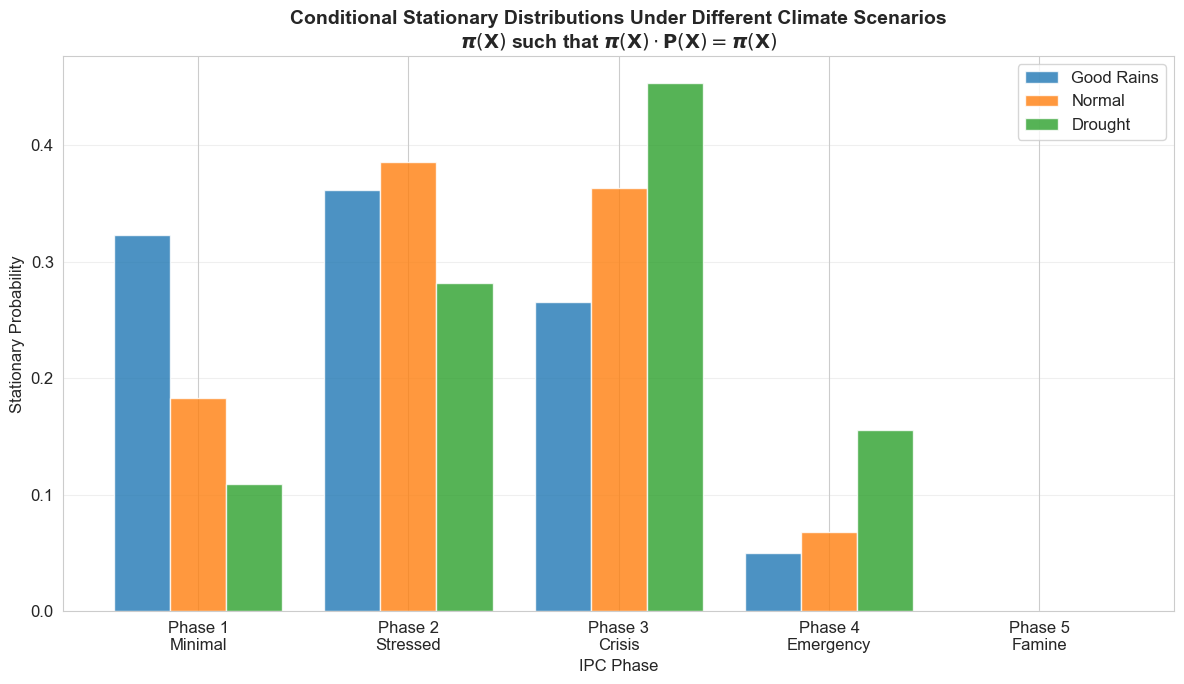

In [20]:
# Visualize with plot_stationary_distribution from src.viz
ax = plot_stationary_distribution(
    stationary_dists,
    title='Conditional Stationary Distributions Under Different Climate Scenarios\n'
          r'$\boldsymbol{\pi}(\mathbf{X})$ such that $\boldsymbol{\pi}(\mathbf{X}) \cdot \mathbf{P}(\mathbf{X}) = \boldsymbol{\pi}(\mathbf{X})$',
    figsize=(12, 7)
)
plt.tight_layout()
plt.show()

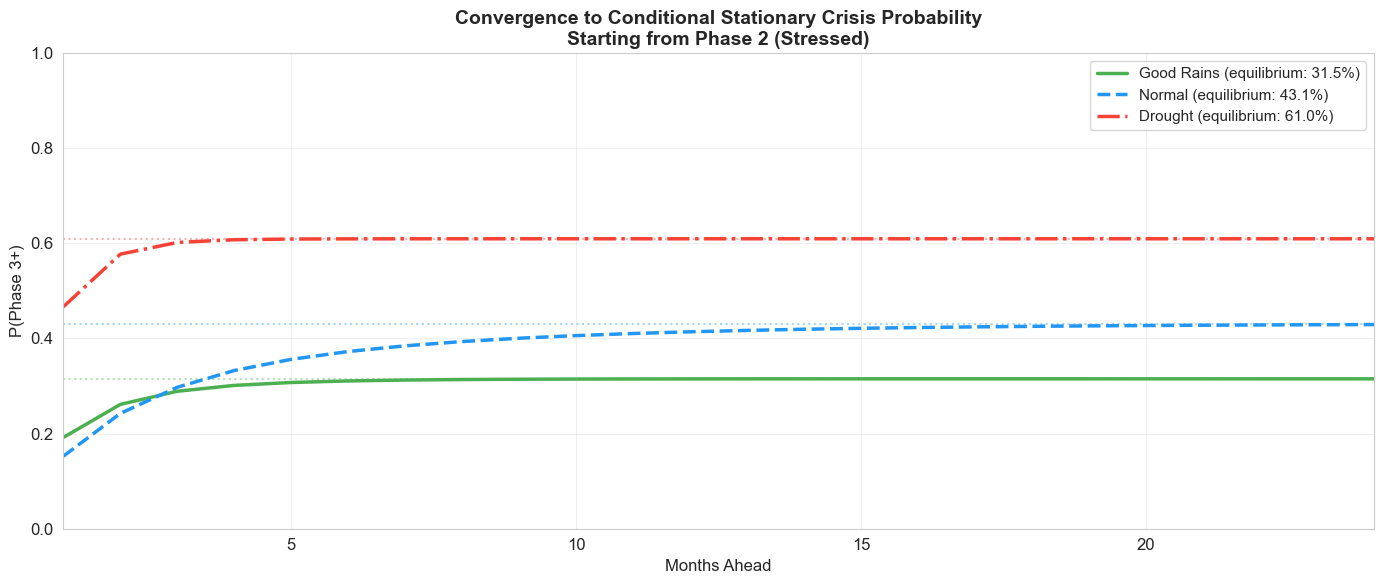


Policy implication:
If drought persisted indefinitely: 61.0% of region-months in Crisis+
If good rains persisted indefinitely: 31.5% of region-months in Crisis+
Difference: 29.4 percentage points

This quantifies the 'climate dividend' of favorable conditions
and the 'drought penalty' of sustained dry conditions.


In [21]:
# Compare convergence rates across scenarios
fig, ax = plt.subplots(figsize=(14, 6))

start_phase = 2  # Start from Phase 2 (Stressed)
horizon = 24

colors = {'Good Rains': '#4CAF50', 'Normal': '#2196F3', 'Drought': '#F44336'}
linestyles = {'Good Rains': '-', 'Normal': '--', 'Drought': '-.'}

for name, P_scenario in scenarios.items():
    # Compute P(Crisis+) at each step
    state_vec = np.zeros(N_STATES)
    state_vec[start_phase - 1] = 1.0
    
    crisis_probs = []
    for t in range(horizon):
        state_vec = state_vec @ P_scenario
        crisis_probs.append(state_vec[2:].sum())
    
    ax.plot(range(1, horizon + 1), crisis_probs,
            color=colors[name], linewidth=2.5, linestyle=linestyles[name],
            label=f'{name} (equilibrium: {stationary_dists[name][2:].sum():.1%})')
    
    # Stationary crisis probability
    ax.axhline(stationary_dists[name][2:].sum(),
               color=colors[name], linestyle=':', alpha=0.4)

ax.set_xlabel('Months Ahead', fontsize=12)
ax.set_ylabel('P(Phase 3+)', fontsize=12)
ax.set_title('Convergence to Conditional Stationary Crisis Probability\n'
             f'Starting from Phase {start_phase} ({IPC_LABELS[start_phase]})',
             fontweight='bold', fontsize=14)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
ax.set_xlim(1, horizon)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

print("\nPolicy implication:")
drought_crisis = stationary_dists['Drought'][2:].sum()
good_crisis = stationary_dists['Good Rains'][2:].sum()
print(f"If drought persisted indefinitely: {drought_crisis:.1%} of region-months in Crisis+")
print(f"If good rains persisted indefinitely: {good_crisis:.1%} of region-months in Crisis+")
print(f"Difference: {(drought_crisis - good_crisis)*100:.1f} percentage points")
print(f"\nThis quantifies the 'climate dividend' of favorable conditions")
print(f"and the 'drought penalty' of sustained dry conditions.")

---
## Summary

This notebook has developed the mathematical framework for food security prediction:

### Homogeneous Markov Chain (Baseline)
- State space $\mathcal{S} = \{1,2,3,4,5\}$ (IPC phases)
- Constant transition matrix $\mathbf{P}$ estimated via MLE
- n-step transitions via Chapman-Kolmogorov: $\mathbf{P}^{(n)} = \mathbf{P}^n$
- Unique stationary distribution $\boldsymbol{\pi}$ (chain is ergodic)
- **Limitation:** Cannot capture climate-dependent transition dynamics

### Non-Homogeneous Markov Chain (Our Model)
- Transition matrix $\mathbf{P}_t = \mathbf{P}(\mathbf{X}_t)$ depends on covariates
- n-step transitions: $\mathbf{P}(s,t) = \prod_{\tau=s}^{t-1} \mathbf{P}_\tau$
- Conditional stationary analysis for scenario comparison
- ML classifiers predict each row of $\mathbf{P}_t$ from features

### Key Quantitative Results
- Strong persistence dominates: diagonal entries of $\mathbf{P}$ range from 40-70%
- Worsening is asymmetrically easier than improvement
- Mixing time $\approx$ 15-20 months
- Drought conditions increase equilibrium crisis burden by 20-30 percentage points

**Next:** Notebook 03 implements the full ML-parameterized NHMC with feature engineering and model training.